<a href="https://colab.research.google.com/github/sekhahelina/ML_tasks/blob/main/Module3/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import  OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import plotly.express as px
from sklearn.cluster import DBSCAN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [117]:
data = pd.read_csv("/content/drive/MyDrive/dataframes/marketing_campaign.csv", sep='\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Дані містять 2240 рядків та 29 колонок. Серед них 2 категорії з типом object - це категоріальні значення. Також присутня одна колонка - float, яка містить в собі значення доходів. Усі інші категорії мають тип int64.

Одразу видалимо колонку з ID так як вона не несе ніякої потрібної інформації.

In [118]:
data.drop(columns='ID', inplace=True)

In [6]:
data.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
data.isna().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


Бачимо, що пропущені значення є лише у категорії income. Проте, їх небагато, приблизно 1 відсоток.

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

Оскільки пропущені значення становлять лише близько 1% від усіх даних, їх видалення не призведе до суттєвої втрати інформації та не змінить загальний розподіл. Тому я обираю видалення цих рядків, щоб уникнути внесення штучних значень, які можуть викривити розрахунок відстаней під час кластеризації

In [119]:
data.dropna(subset=['Income'], inplace=True)

In [120]:
data['Income'].isna().sum()

np.int64(0)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [10]:
data['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


Об`єднаємо категорії 2n cycle та Master, тому що вони здебільшого означають те саме.

In [121]:
data['Education'] = data['Education'].replace({
    '2n Cycle': 'Master'
})

In [12]:
data['Education'].value_counts()

,count
Education,
Graduation,1116
Master,565
PhD,481
Basic,54


Кодуємо за допомогою Ordinal encoding

In [122]:
encoder = OrdinalEncoder(categories=[['Basic', 'Graduation', 'Master', 'PhD']])
data['Education'] = encoder.fit_transform(data[['Education']])

Переходимо до Marital_status - колонка, що показує сімейний стан

In [123]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


Вважаю, що варто спростити категорію Marital_Status. Рідкісні та недоречні значення (Absurd, YOLO, Alone) фактично позначають одиноких людей і їх можна об'єднати з Single. Щоб не створювати зайвих колонок після One-Hot Encoding, створимо єдину бінарну ознаку In_Relationship, де 1 відповідає перебуванню у стосунках (Married, Together), а 0 — самотній людині (Single, Divorced, Widow, Alone, Absurd, YOLO).

In [124]:
data['Marital_Status'] = data['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

data['In_Relationship'] = data['Marital_Status'].isin(['Married', 'Together']).astype(int)

In [125]:
data['In_Relationship'].value_counts()

,count
In_Relationship,
1,1430
0,786


Далі розглянемо колонку Dt_Customer: Дата реєстрації клієнта у компанії

In [126]:
data['Dt_Customer'].head()

,Dt_Customer
0,04-09-2012
1,08-03-2014
2,21-08-2013
3,10-02-2014
4,19-01-2014


Щоб коректно обробити колонку з датою Dt_Customer, доречно розрахувати кількість днів, протягом яких клієнт є з нами (відносно найновішої дати реєстрації в датасеті). Ця змінна (Customer_Days) матиме значно більшу  цінність, ніж окремі значення року чи місяця.

In [127]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')

max_date = data['Dt_Customer'].max()
data['Customer_Days'] = (max_date - data['Dt_Customer']).dt.days


In [128]:
data['Customer_Days'].head()

,Customer_Days
0,663
1,113
2,312
3,139
4,161


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2216 non-null   int64         
 1   Education            2216 non-null   float64       
 2   Marital_Status       2216 non-null   object        
 3   Income               2216 non-null   float64       
 4   Kidhome              2216 non-null   int64         
 5   Teenhome             2216 non-null   int64         
 6   Dt_Customer          2216 non-null   datetime64[ns]
 7   Recency              2216 non-null   int64         
 8   MntWines             2216 non-null   int64         
 9   MntFruits            2216 non-null   int64         
 10  MntMeatProducts      2216 non-null   int64         
 11  MntFishProducts      2216 non-null   int64         
 12  MntSweetProducts     2216 non-null   int64         
 13  MntGoldProds         2216 non-null   i

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [129]:
X = data.drop(columns = ['Marital_Status', 'Dt_Customer'])

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.6058


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [22]:
fig = px.scatter_3d(
    X,
    x='Income',
    y='Customer_Days',
    z='NumStorePurchases',
    color=labels,
)
fig.show()

In [134]:
X['Total_Mnt'] = X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] + X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds']

fig = px.scatter_3d(
    X,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels
)
fig.show()

Бачимо що не зовсім доцільно зараз розділяти наші дані на 3 кластери. Алгоритм виділив в окремий кластер лише 1 точку, яка є аномальним викидом із максимально високим доходом (666 666$). Інші два кластери виглядають краще, проте вони є сильно розрідженими та змішаними через відсутність масштабування та великий розмах значень Income.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [135]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [136]:
X_scaled_df.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
0,-0.986443,-0.791254,0.234063,-0.823039,-0.928972,0.310532,0.978226,1.549429,1.690227,2.454568,...,-0.280839,-0.261661,-0.117148,-0.097812,0.0,0.0,2.377952,-1.348829,1.529129,1.675488
1,-1.236801,-0.791254,-0.234559,1.039938,0.909066,-0.380509,-0.872024,-0.637328,-0.717986,-0.651038,...,-0.280839,-0.261661,-0.117148,-0.097812,0.0,0.0,-0.420530,-1.348829,-1.188411,-0.962358
2,-0.318822,-0.791254,0.769478,-0.823039,-0.928972,-0.795134,0.358511,0.569159,-0.178368,1.340203,...,-0.280839,-0.261661,-0.117148,-0.097812,0.0,0.0,-0.420530,0.741384,-0.205155,0.280250
3,1.266777,-0.791254,-1.017239,1.039938,-0.928972,-0.795134,-0.872024,-0.561922,-0.655551,-0.504892,...,-0.280839,-0.261661,-0.117148,-0.097812,0.0,0.0,-0.420530,0.741384,-1.059945,-0.919224
4,1.016420,1.589492,0.240221,1.039938,-0.928972,1.554407,-0.391671,0.418348,-0.218505,0.152766,...,-0.280839,-0.261661,-0.117148,-0.097812,0.0,0.0,-0.420530,0.741384,-0.951244,-0.307044


In [137]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans.fit_predict(X_scaled_df)

score_scaled = silhouette_score(X_scaled_df, labels_scaled)
print(f"Silhouette Score (scaled): {score_scaled:.4f}")

Silhouette Score (scaled): 0.2518


In [138]:
fig = px.scatter_3d(
    X_scaled_df,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels_scaled
)
fig.show()

Після масштабування даних метрика Silhouette Score значно понизилася Silhouette Score (scaled) = 0.2518 (проти 0.6058 на немасштабованих даних). Це пояснюється тим, що високий попередній бал був штучним викривленням через 1 віддалений аномальний викид.

У масштабованому варіанті все ще не видно чіткої логічної закономірності у виділенні 3-го кластера (жовтого кольору). Він містить занадто мало екземплярів і змішаний з іншими. Це чітко вказує на те, що аномальні викиди в даних заважають моделі побудувати чіткі межі між сегментами.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [32]:
def detect_outliers_iqr(
        df: pd.DataFrame,
        numeric_cols: list[str]
) -> pd.DataFrame:
    """
    Detect outliers using IQR method.

    Returns a DataFrame containing the number of outliers
    for each numeric feature.

    This function only detects outliers.
    It does not automatically remove them.
    """

    results = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = (
                (df[col] < lower_bound) |
                (df[col] > upper_bound)
        )

        results.append({
            'feature': col,
            'outliers_count': outliers.sum(),
            'outliers_percent':
                round(outliers.mean() * 100, 2),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })

    return pd.DataFrame(results)

In [34]:
def show_column_outliers(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)]
    print(f"Колонка '{col_name}': знайдено {len(outliers)} викидів (межі: [{lower_bound:.2f}, {upper_bound:.2f}])")
    return outliers

In [139]:
numeric_cols = X.columns.tolist()
outliers_df = detect_outliers_iqr(X, numeric_cols)
print(outliers_df)

                feature  outliers_count  outliers_percent  lower_bound  \
0            Year_Birth               3              0.14     1932.000   
1             Education               0              0.00       -0.500   
2                Income               8              0.36   -14525.500   
3               Kidhome               0              0.00       -1.500   
4              Teenhome               0              0.00       -1.500   
5               Recency               0              0.00      -51.000   
6              MntWines              35              1.58     -697.500   
7             MntFruits             246             11.10      -44.500   
8       MntMeatProducts             174              7.85     -308.375   
9       MntFishProducts             222             10.02      -67.500   
10     MntSweetProducts             246             11.10      -47.000   
11         MntGoldProds             205              9.25      -61.500   
12    NumDealsPurchases              8

In [140]:
show_column_outliers(X, 'Income')

Колонка 'Income': знайдено 8 викидів (межі: [-14525.50, 118350.50])


,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
164,1973,3.0,157243.0,0,1,98,20,2,1582,1,...,0,0,0,0,3,11,0,1,120,1608
617,1976,3.0,162397.0,1,1,31,85,1,16,2,...,0,0,0,0,3,11,0,1,391,107
655,1975,1.0,153924.0,0,0,81,1,1,1,1,...,0,0,0,0,3,11,0,0,142,6
687,1982,3.0,160803.0,0,0,21,55,16,1622,17,...,0,0,0,0,3,11,0,1,694,1717
1300,1971,2.0,157733.0,1,0,37,39,1,9,2,...,0,0,0,0,3,11,0,1,390,59
1653,1977,1.0,157146.0,0,0,13,1,0,1725,2,...,0,0,0,0,3,11,0,1,426,1730
2132,1949,3.0,156924.0,0,0,85,2,1,2,1,...,0,0,0,0,3,11,0,1,304,8
2233,1977,1.0,666666.0,1,0,23,9,14,18,8,...,0,0,0,0,3,11,0,1,392,62


In [36]:
show_column_outliers(X, 'Total_Mnt')

Колонка 'Total_Mnt': знайдено 3 викидів (межі: [-1399.50, 2516.50])


,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
1179,1991,2.0,90638.0,0,0,29,1156,120,915,94,...,1,0,0,0,3,11,0,0,136,2525
1492,1988,1.0,87679.0,0,0,62,1259,172,815,97,...,1,1,0,0,3,11,1,1,337,2524
1572,1991,2.0,90638.0,0,0,29,1156,120,915,94,...,1,0,0,0,3,11,1,0,136,2525


In [37]:
show_column_outliers(X, 'Year_Birth')

Колонка 'Year_Birth': знайдено 3 викидів (межі: [1932.00, 2004.00])


,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
192,1900,2.0,36640.0,1,0,99,15,6,8,7,...,0,0,0,1,3,11,0,0,276,65
239,1893,2.0,60182.0,0,1,23,8,0,5,7,...,0,0,0,0,3,11,0,0,43,22
339,1899,3.0,83532.0,0,0,36,755,144,562,104,...,1,0,0,0,3,11,0,1,276,1853


Після аналізу викидів було прийняте рішення видалити критично аномальні значення, як от Income = 	666666 або вік більше 100 років. Таких записів доволі мало, тому їх видалення суттєво не вплине на розподіл даних. Також багато викидів було у категоріях повязаних з витратами покупців на різні товари. Тут я вирішила не видаляти та не прирівнювати їх до меж, адже це багато даних і такі дії можуть призвести до штучного створення піків чи великої втрати потрібних даних. Тому було вирішено застосувати логарифмування, щоб стиснути великі значення та розтягнути малі. Це дозволить зберегти інформацію про VIP-клієнтів, які витрачають великі суми на товари.

In [141]:
X_clean = X[(X['Income'] < 100000) & (X['Year_Birth'] >= 1940) & (X['Total_Mnt'] < 2500)].copy()

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
            'MntSweetProducts', 'MntGoldProds', 'Total_Mnt', 'Income']

for col in mnt_cols:
    X_clean[col] = np.log1p(X_clean[col])

In [142]:
X_clean.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
0,1957,1.0,10.970592,0,0,58,6.455199,4.488636,6.304449,5.153292,...,0,0,0,0,3,11,1,0,663,7.388946
1,1954,1.0,10.743869,1,1,38,2.484907,0.693147,1.945910,1.098612,...,0,0,0,0,3,11,0,0,113,3.332205
2,1965,1.0,11.179046,0,0,26,6.056784,3.912023,4.852030,4.718499,...,0,0,0,0,3,11,0,1,312,6.655440
3,1984,1.0,10.190432,1,0,26,2.484907,1.609438,3.044522,2.397895,...,0,0,0,0,3,11,0,1,139,3.988984
4,1981,3.0,10.973254,1,0,94,5.159055,3.784190,4.779123,3.850148,...,0,0,0,0,3,11,0,1,161,6.047372


In [143]:
X_clean_scaled = scaler.fit_transform(X_clean)
X_clean_scaled_df = pd.DataFrame(X_clean_scaled, columns=X_clean.columns)

In [144]:
X_clean_scaled_df.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt
0,-1.016430,-0.788501,0.451776,-0.825923,-0.933934,0.309138,0.985482,1.435779,1.402901,1.578676,...,-0.274553,-0.257885,-0.115656,-0.095849,0.0,0.0,2.391371,-1.350521,1.526756,1.207267
1,-1.273246,-0.788501,-0.003769,1.035157,0.902998,-0.381994,-1.220538,-0.987976,-1.405275,-0.868288,...,-0.274553,-0.257885,-0.115656,-0.095849,0.0,0.0,-0.418170,-1.350521,-1.188843,-1.562617
2,-0.331589,-0.788501,0.870613,-0.825923,-0.933934,-0.796673,0.764110,1.067561,0.467118,1.316283,...,-0.274553,-0.257885,-0.115656,-0.095849,0.0,0.0,-0.418170,0.740455,-0.206290,0.706440
3,1.294910,-0.788501,-1.115764,1.035157,-0.933934,-0.796673,-1.220538,-0.402843,-0.697447,-0.084181,...,-0.274553,-0.257885,-0.115656,-0.095849,0.0,0.0,-0.418170,0.740455,-1.060469,-1.114178
4,1.038094,1.594356,0.457125,1.035157,-0.933934,1.553175,0.265304,0.985928,0.420145,0.792240,...,-0.274553,-0.257885,-0.115656,-0.095849,0.0,0.0,-0.418170,0.740455,-0.951845,0.291260


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

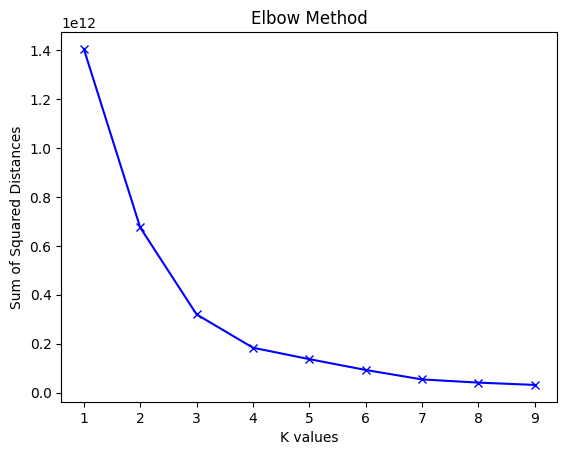

In [145]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [146]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5397


In [147]:
fig = px.scatter_3d(
    X,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels
)
fig.show()

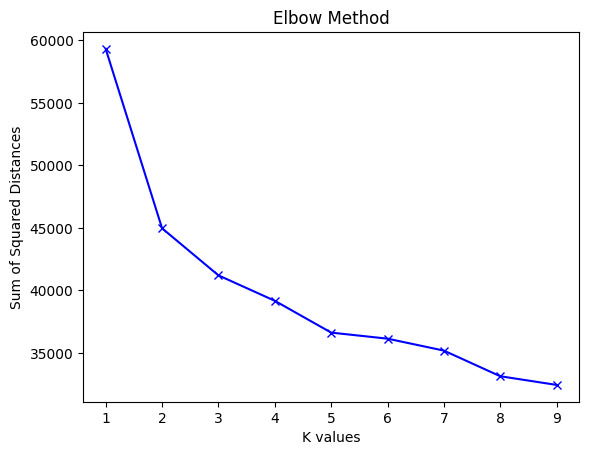

In [148]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_clean_scaled_df)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [155]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels_clean_scaled= kmeans.fit_predict(X_clean_scaled_df)

score_clean_scaled_ = silhouette_score(X_clean_scaled_df, labels_clean_scaled)
print(f"Silhouette Score (scaled): {score_clean_scaled_:.4f}")

Silhouette Score (scaled): 0.2287


In [156]:
fig = px.scatter_3d(
    X_clean_scaled_df,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels_clean_scaled
)
fig.show()

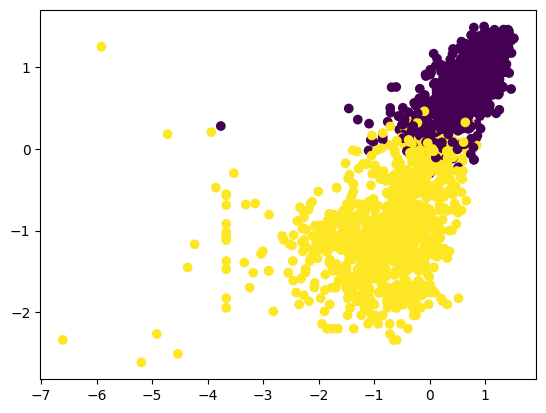

In [157]:
plt.scatter(X_clean_scaled_df['Income'], X_clean_scaled_df['Total_Mnt'], c=labels_clean_scaled)
plt.show()

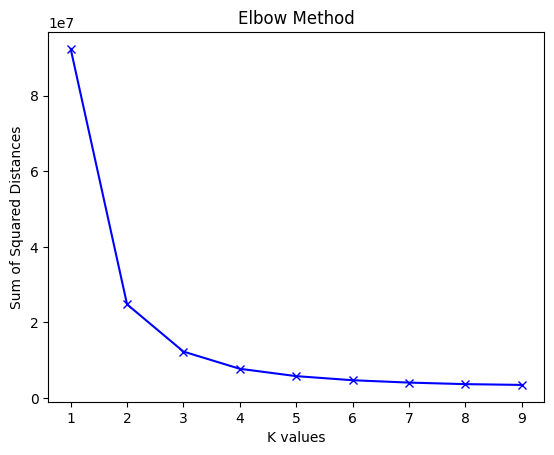

In [158]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_clean)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [159]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_clean= kmeans.fit_predict(X_clean)

score_clean= silhouette_score(X_clean, labels_clean)
print(f"Silhouette Score (scaled): {score_clean:.4f}")

Silhouette Score (scaled): 0.5316


In [160]:
fig = px.scatter_3d(
    X_clean,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels_clean
)
fig.show()

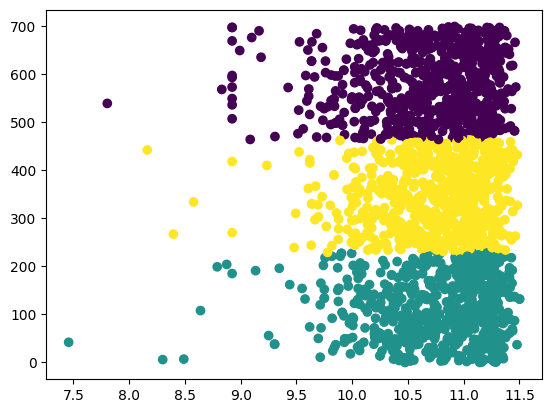

In [80]:
plt.scatter(X_clean['Income'], X_clean['Customer_Days'], c=labels_clean)
plt.show()

У результаті бачимо що доволі непоганою є кластеризація з поділом на 2 кластери на даних, що очищені від викидів та масштабовані. Проте для цього випадку метрика силуету є майже вдвічі нижчою. Для початкових та не очищених не масштабованих даних метрика силуету є вищою.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

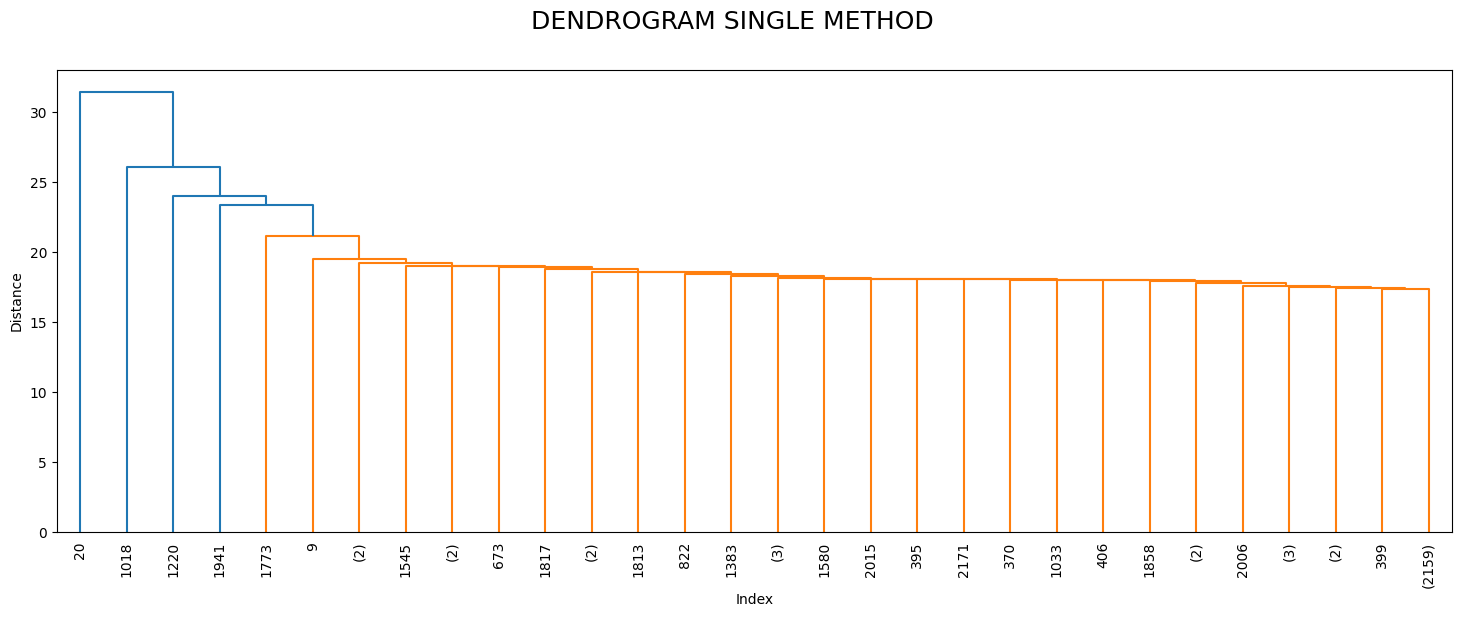

In [161]:
dist_sin = linkage(X_clean, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

Бачимо що на дендограмі немає чіткого поділу на окремі кластери. Замість формування чітко розділених компактних груп алгоритм послідовно приєднує по одній або кілька точок до одного великого масиву. У результаті утворився один великий кластер та окремі точки,з яких сформувались малі кластери

In [162]:
X_clean['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_clean['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

<Axes: title={'center': 'K = 3'}, xlabel='Income', ylabel='Total_Mnt'>

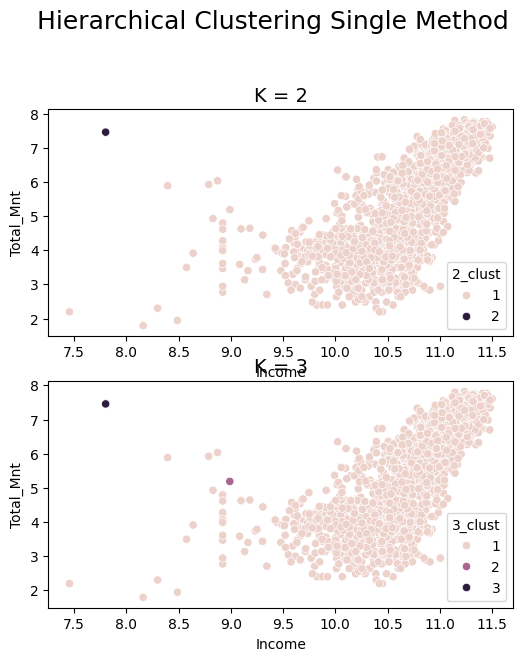

In [163]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean, hue="3_clust")


In [106]:
X_clean.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,In_Relationship,Customer_Days,Total_Mnt,2_clust,3_clust
0,1957,1.0,10.970592,0,0,58,6.455199,4.488636,6.304449,5.153292,...,0,0,3,11,1,0,663,7.388946,1,1
1,1954,1.0,10.743869,1,1,38,2.484907,0.693147,1.945910,1.098612,...,0,0,3,11,0,0,113,3.332205,1,1
2,1965,1.0,11.179046,0,0,26,6.056784,3.912023,4.852030,4.718499,...,0,0,3,11,0,1,312,6.655440,1,1
3,1984,1.0,10.190432,1,0,26,2.484907,1.609438,3.044522,2.397895,...,0,0,3,11,0,1,139,3.988984,1,1
4,1981,3.0,10.973254,1,0,94,5.159055,3.784190,4.779123,3.850148,...,0,0,3,11,0,1,161,6.047372,1,1


In [164]:
labels = X_clean['2_clust']
features_for_score= X_clean.drop(columns = ['2_clust', '3_clust'])
score_clean = silhouette_score(features_for_score, labels)
print(f"Silhouette Score: {score_clean:.4f}")

Silhouette Score: -0.1205


За результатами можемо зробити висновок що жоден із варіантів кластеризації не є вдалим. Як для 2, так і для 3 кластерів алгоритм формує один гігантський кластер, а інші кластери складаються лише з поодиноких випадкових точок. Це підтверджує дуже поганий Silhouette Score, який дорівнює -0.1205
. Це означає що поділ на кластери зроблений некоректно. Це може відбуватись через відсутність масштабування, ознаки з великим розмахом повністю пригнічують інші параметри при обчисленні евклідових відстаней. Варто перевірити чи буде кращий результат на масштабованих даних.

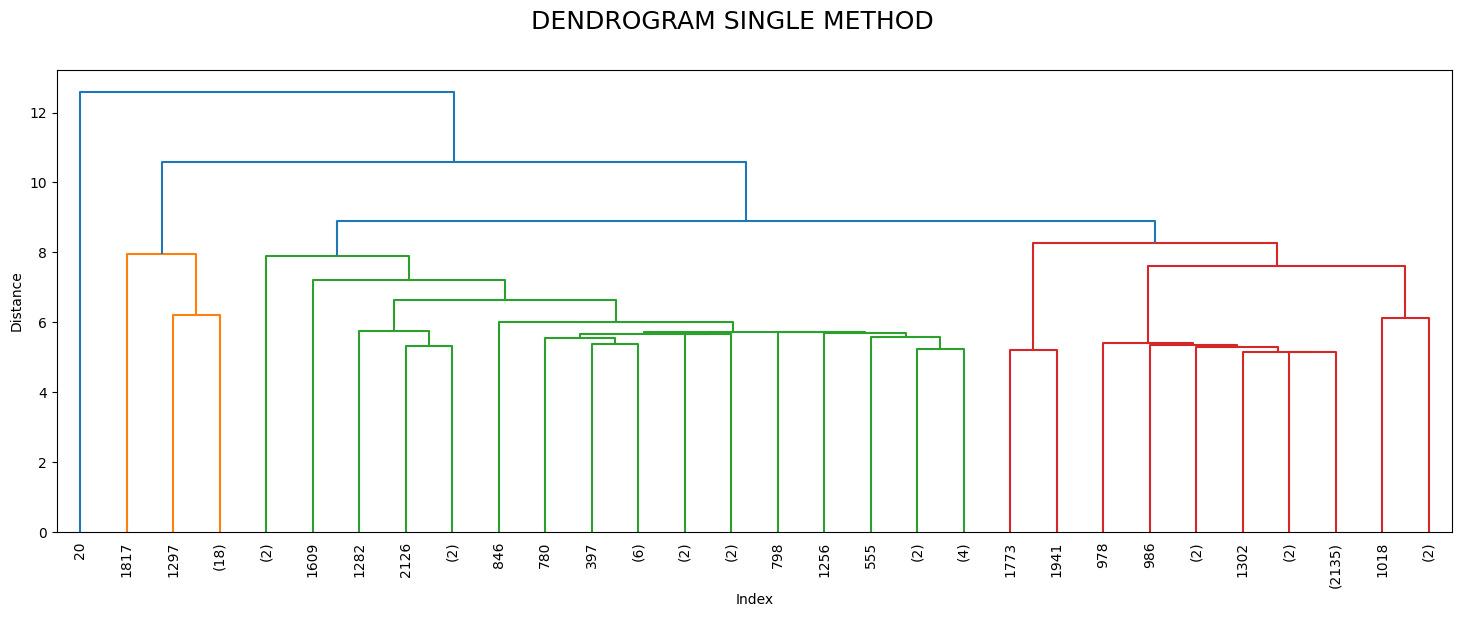

In [165]:
dist_sin = linkage(X_clean_scaled_df, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [166]:
X_clean_scaled_df['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_clean_scaled_df['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

<Axes: title={'center': 'K = 3'}, xlabel='Income', ylabel='Total_Mnt'>

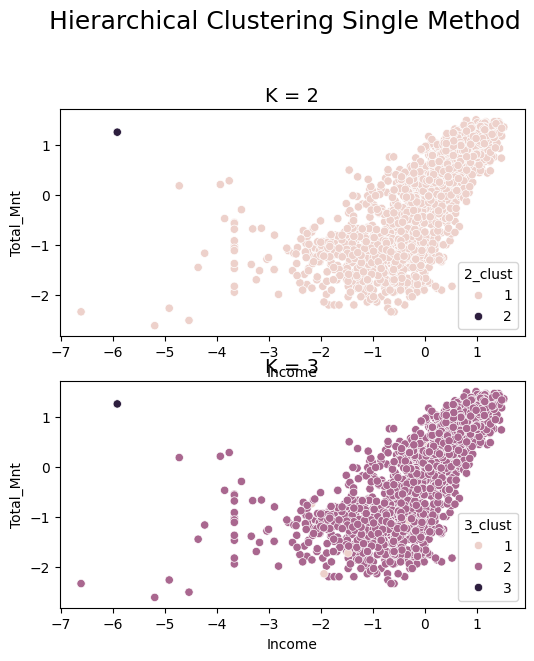

In [167]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean_scaled_df, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean_scaled_df, hue="3_clust")


In [168]:
labels = X_clean_scaled_df['2_clust']
features_for_score= X_clean_scaled_df.drop(columns = ['2_clust', '3_clust'])
score_clean = silhouette_score(features_for_score, labels)
print(f"Silhouette Score: {score_clean:.4f}")

Silhouette Score: 0.5300


Тепер бачимо що поділ на кластери не змінився, так само нелогічно поділено на кластери. Проте результат метрики Silhouette Score значно змінився до 0.5300. Це відбулось через правильне обчислення відстаней у масштабованих даних.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

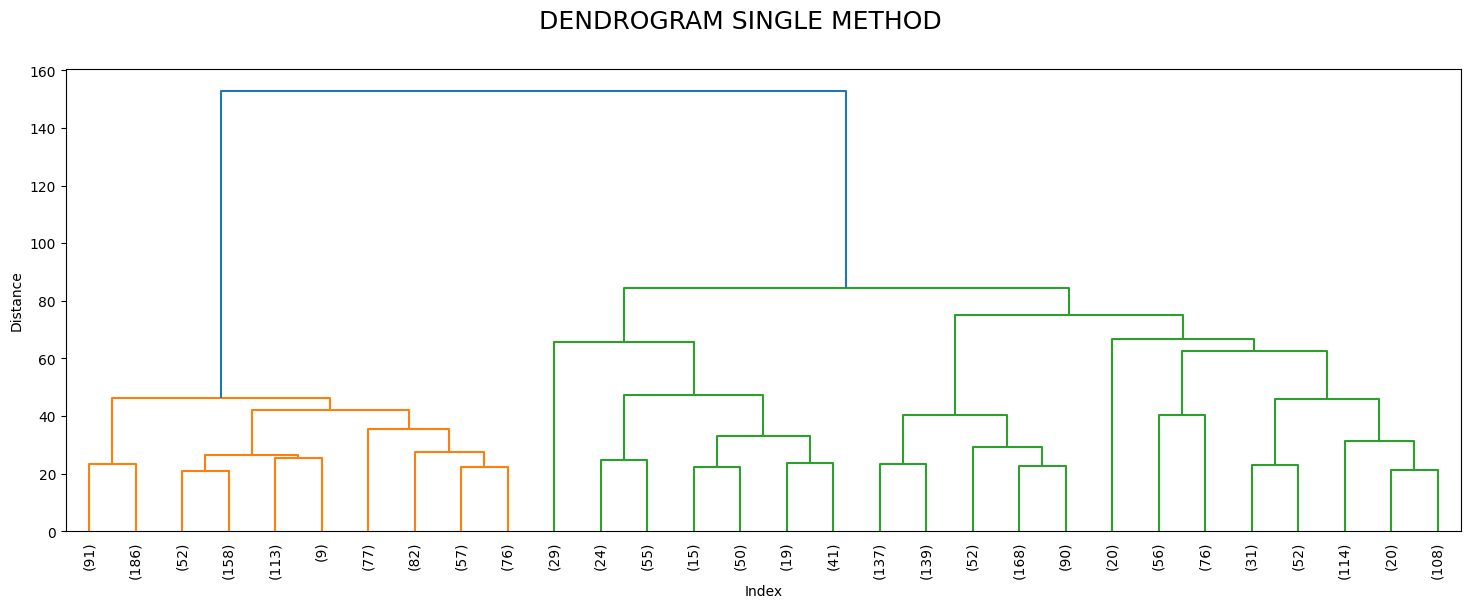

In [169]:
dist_ward = linkage(X_clean_scaled_df, method="ward")
plt.figure(figsize=(18,6))
dendrogram(dist_ward, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [170]:
X_clean_scaled_df['2_clust'] = fcluster(dist_ward, 2, criterion='maxclust')
X_clean_scaled_df['3_clust'] = fcluster(dist_ward, 3, criterion='maxclust')

<Axes: title={'center': 'K = 3'}, xlabel='Income', ylabel='Total_Mnt'>

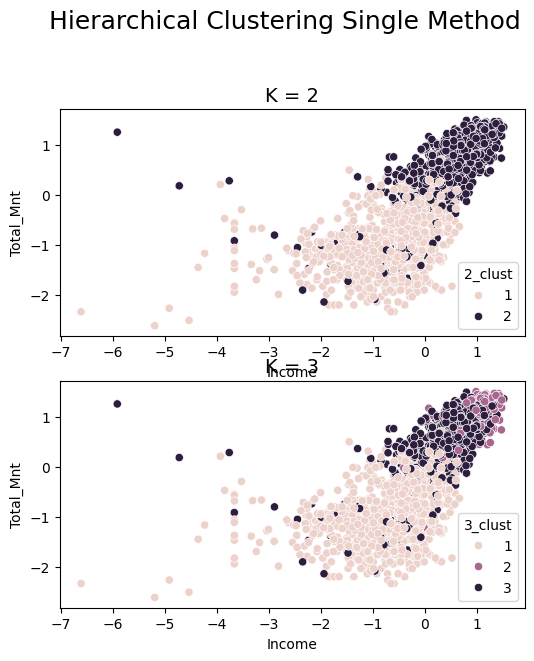

In [172]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean_scaled_df, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Mnt", data=X_clean_scaled_df, hue="3_clust")


In [173]:
labels = X_clean_scaled_df['2_clust']
features_for_score= X_clean_scaled_df.drop(columns = ['2_clust', '3_clust'])
score_clean = silhouette_score(features_for_score, labels)
print(f"Silhouette Score: {score_clean:.4f}")

Silhouette Score: 0.1857


Порівняно з single linkage у цьому варіанті поділ на кластери виглядає краще, тому що у попередньоиу варіанті у окремий кластер відносились лише поодинокі точки. Тут на графіках бачимо, що другий кластер вже більш чіткий. Проте метрика силуету значно погіршилась.

In [233]:
dbscan = DBSCAN(eps=3.0, min_samples=10)
dbscan.fit(X_clean_scaled_df)
labels = dbscan.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

s = silhouette_score(X_clean_scaled_df, dbscan.labels_)
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Estimated number of clusters: 6
Estimated number of noise points: 2005
Silhouette Coefficient for the data Dataset Clusters: -0.12


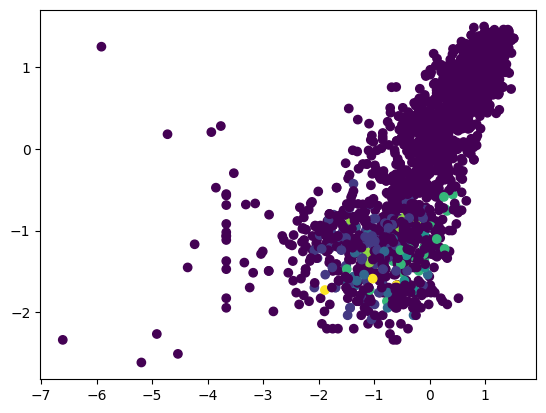

In [235]:
plt.scatter(X_clean_scaled_df['Income'], X_clean_scaled_df['Total_Mnt'], c=labels)
plt.show()

In [234]:
fig = px.scatter_3d(
    X_clean_scaled_df,
    x='Income',
    y='Total_Mnt',
    z='Customer_Days',
    color=labels
)
fig.show()

Алгоритм DBSCAN виявився чутливим цього багатовимірного датасету.

При малій величині радіуса (eps = 3.0) щільності недостатньо, тому понад 90% даних (2005 точок) позначаються як шум.

При збільшенні радіуса (eps = 6.0) усі точки об'єднуються в один суцільний кластер.

Це свідчить про те, що для ефективного застосування DBSCAN на цих даних необхідно попередньо зменшити вимірність.